In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
datos = pd.read_csv("../data/processed/datos_limpios.csv")
datos.head()

,salario_bruto,seniority,experiencia,nivel_estudios,estado_estudios,lenguajes,genero,es_dolarizado
0,3000000.0,Senior,15,NaN,NaN,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",Mujer Cis,True
1,5000000.0,Senior,25,NaN,NaN,".NET, C#, HTML, Javascript, SQL",Mujer Cis,True
2,4600000.0,Senior,7,Universitario,Completo,"Go, SQL",Mujer Cis,True
3,7800000.0,Senior,25,NaN,NaN,Ninguno de los anteriores,Hombre Cis,True
4,3500000.0,Semi-Senior,3,NaN,NaN,"Bash/Shell, Python",Hombre Cis,True


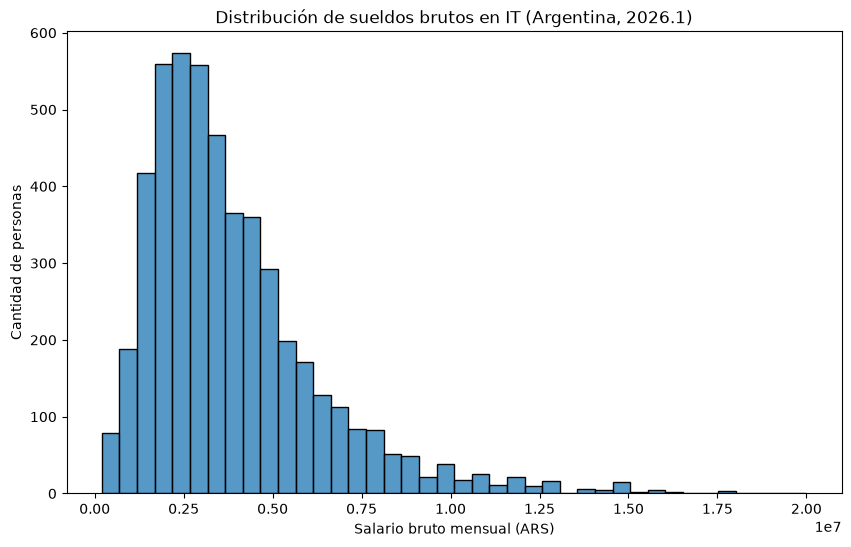

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=datos, x="salario_bruto", bins=40)
plt.title("Distribución de sueldos brutos en IT (Argentina, 2026.1)")
plt.xlabel("Salario bruto mensual (ARS)")
plt.ylabel("Cantidad de personas")
plt.show()

In [5]:
print("Media:  ", datos["salario_bruto"].mean())
print("Mediana:", datos["salario_bruto"].median())

Media:   3876029.081034622
Mediana: 3268000.0


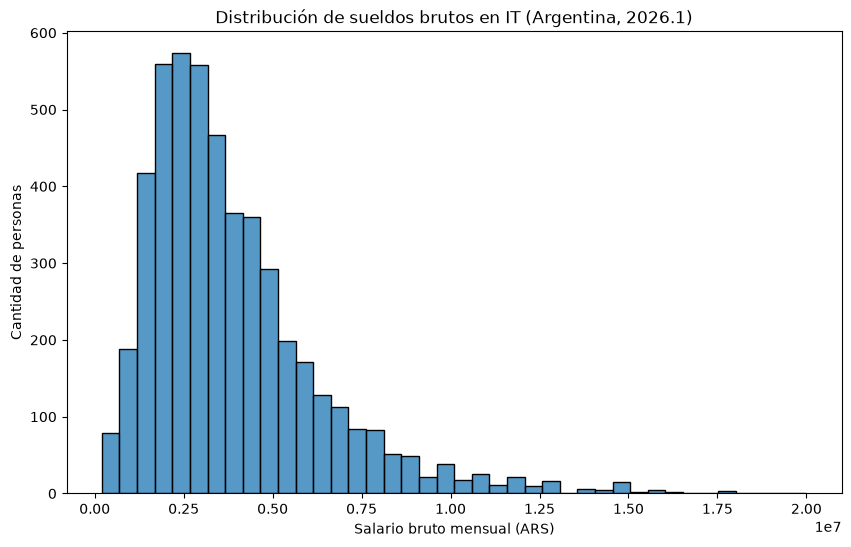

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=datos, x="salario_bruto", bins=40)
plt.title("Distribución de sueldos brutos en IT (Argentina, 2026.1)")
plt.xlabel("Salario bruto mensual (ARS)")
plt.ylabel("Cantidad de personas")
plt.savefig("../visualizations/01_histograma_sueldos.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
import os
os.listdir("../visualizations")

['.gitkeep',
 '.ipynb_checkpoints',
 '01_histograma_sueldos.png',
 '02_boxplot_seniority.png',
 '03_scatter_experiencia.png',
 '04_scatter_experiencia_seniority.png',
 '05_boxplot_dolarizado.png']

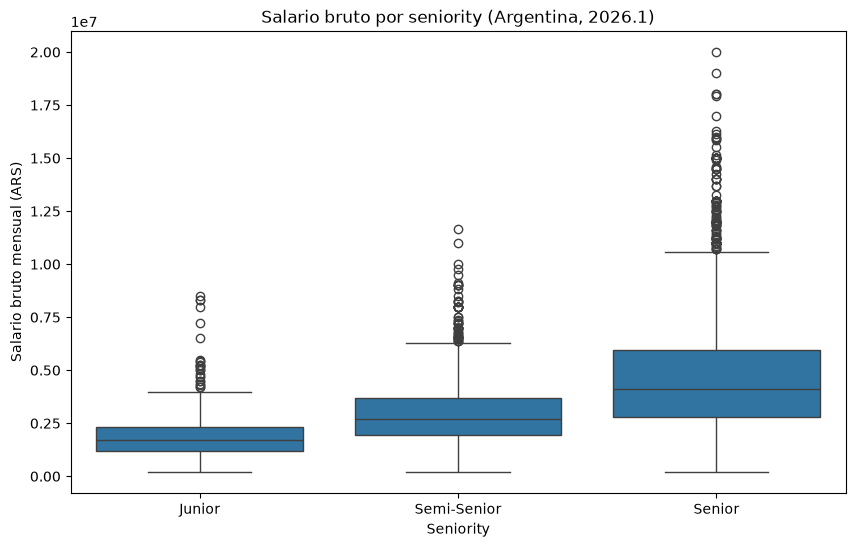

In [8]:
orden = ["Junior", "Semi-Senior", "Senior"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=datos, x="seniority", y="salario_bruto", order=orden)
plt.title("Salario bruto por seniority (Argentina, 2026.1)")
plt.xlabel("Seniority")
plt.ylabel("Salario bruto mensual (ARS)")
plt.savefig("../visualizations/02_boxplot_seniority.png", dpi=150, bbox_inches="tight")
plt.show()

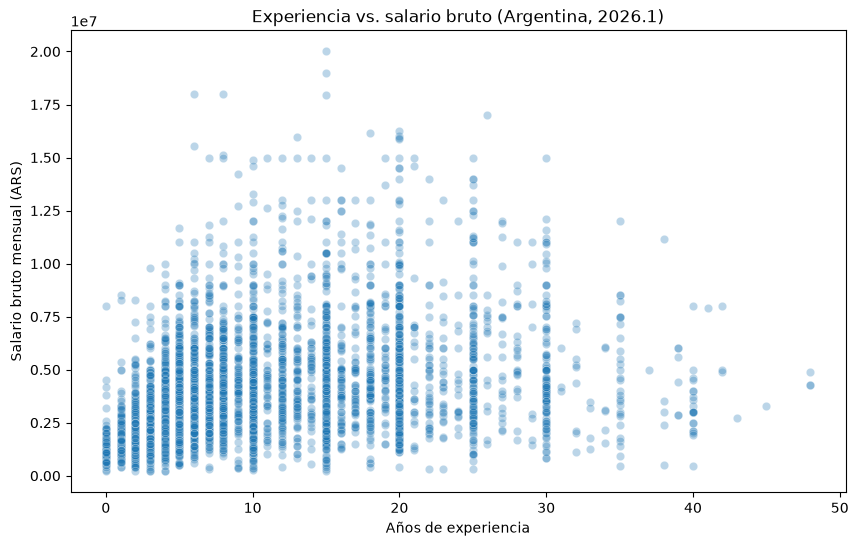

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datos, x="experiencia", y="salario_bruto", alpha=0.3)
plt.title("Experiencia vs. salario bruto (Argentina, 2026.1)")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario bruto mensual (ARS)")
plt.savefig("../visualizations/03_scatter_experiencia.png", dpi=150, bbox_inches="tight")
plt.show()

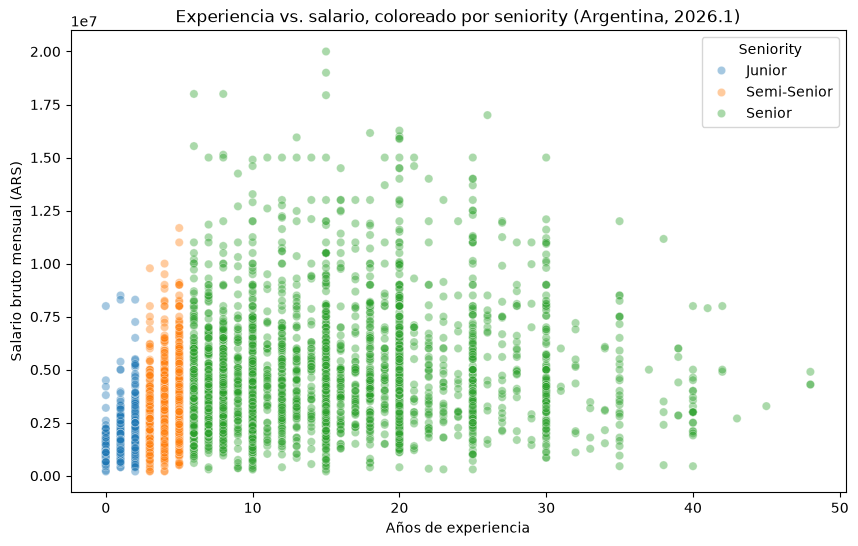

In [10]:
orden = ["Junior", "Semi-Senior", "Senior"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=datos, x="experiencia", y="salario_bruto",
                hue="seniority", hue_order=orden, alpha=0.4)
plt.title("Experiencia vs. salario, coloreado por seniority (Argentina, 2026.1)")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario bruto mensual (ARS)")
plt.legend(title="Seniority")
plt.savefig("../visualizations/04_scatter_experiencia_seniority.png", dpi=150, bbox_inches="tight")
plt.show()

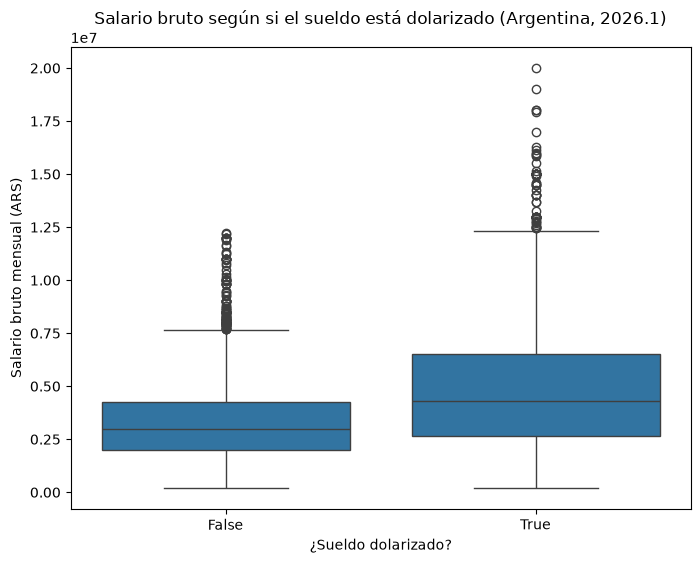

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=datos, x="es_dolarizado", y="salario_bruto")
plt.title("Salario bruto según si el sueldo está dolarizado (Argentina, 2026.1)")
plt.xlabel("¿Sueldo dolarizado?")
plt.ylabel("Salario bruto mensual (ARS)")
plt.savefig("../visualizations/05_boxplot_dolarizado.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
datos.groupby("es_dolarizado")["salario_bruto"].median()

es_dolarizado
False    3000000.0
True     4300000.0
Name: salario_bruto, dtype: float64

In [13]:
from scipy import stats

In [14]:
# Separamos el sueldo de cada grupo
dolarizados = datos[datos["es_dolarizado"] == True]["salario_bruto"]
pesos = datos[datos["es_dolarizado"] == False]["salario_bruto"]

# Test de Mann-Whitney U
u_stat, p_valor = stats.mannwhitneyu(dolarizados, pesos)

print("p-valor:", p_valor)

p-valor: 2.443602995415726e-68


In [15]:
orden = ["Junior", "Semi-Senior", "Senior"]
datos.groupby("seniority")["salario_bruto"].median().reindex(orden)

seniority
Junior         1700000.0
Semi-Senior    2700000.0
Senior         4100000.0
Name: salario_bruto, dtype: float64

In [16]:
# Separamos el sueldo de cada grupo de seniority
junior = datos[datos["seniority"] == "Junior"]["salario_bruto"]
semi = datos[datos["seniority"] == "Semi-Senior"]["salario_bruto"]
senior = datos[datos["seniority"] == "Senior"]["salario_bruto"]

# Test de Kruskal-Wallis (compara los 3 grupos a la vez)
h_stat, p_valor = stats.kruskal(junior, semi, senior)

print("p-valor:", p_valor)

p-valor: 9.966666029083942e-238


In [17]:
# Junior vs Semi-Senior
u1, p_junior_semi = stats.mannwhitneyu(junior, semi)

# Semi-Senior vs Senior
u2, p_semi_senior = stats.mannwhitneyu(semi, senior)

print("Junior vs Semi-Senior -> p:", p_junior_semi)
print("Semi-Senior vs Senior -> p:", p_semi_senior)

Junior vs Semi-Senior -> p: 2.604157088439463e-62
Semi-Senior vs Senior -> p: 2.7999930973752246e-118


In [18]:
coef, p_valor = stats.spearmanr(datos["experiencia"], datos["salario_bruto"])

print("Coeficiente de Spearman:", coef)
print("p-valor:", p_valor)

Coeficiente de Spearman: 0.46669551516307217
p-valor: 1.0824520194553529e-265
